# Visualisatie — Seaborn

**Seaborn** is gebouwd bovenop Matplotlib en maakt het eenvoudiger om **statistische visualisaties** te maken. Met minder code krijg je mooiere en informatierijkere grafieken.

Seaborn blinkt uit in:
- Distributie-visualisaties
- Correlatie-heatmaps
- Categorie-vergelijkingen
- Pairplots voor een snelle verkenning van alle variabelen

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")  # consistent style

penguins = sns.load_dataset("penguins").dropna()
titanic = sns.load_dataset("titanic")
tips = sns.load_dataset("tips")

## Distributies — `histplot` en `kdeplot`

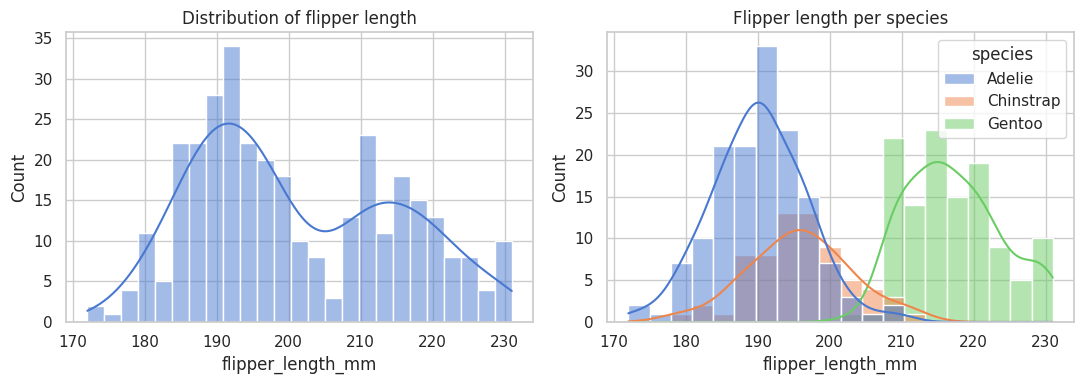

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram with KDE (Kernel Density Estimate) overlay
sns.histplot(penguins["flipper_length_mm"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("Distribution of flipper length")

# Histogram per category with hue
sns.histplot(penguins, x="flipper_length_mm", hue="species", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Flipper length per species")

plt.tight_layout()
plt.show()

## Boxplot — verdeling per categorie

Een **boxplot** toont de mediaan, kwartielen en uitschieters van een numerieke variabele per categorie.

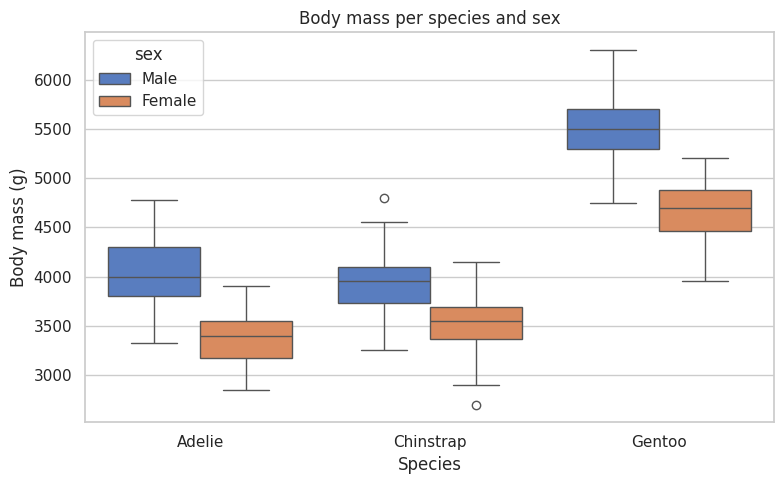

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    ax=ax,
)
ax.set_title("Body mass per species and sex")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")

plt.tight_layout()
plt.show()

## Scatter plot — `scatterplot`

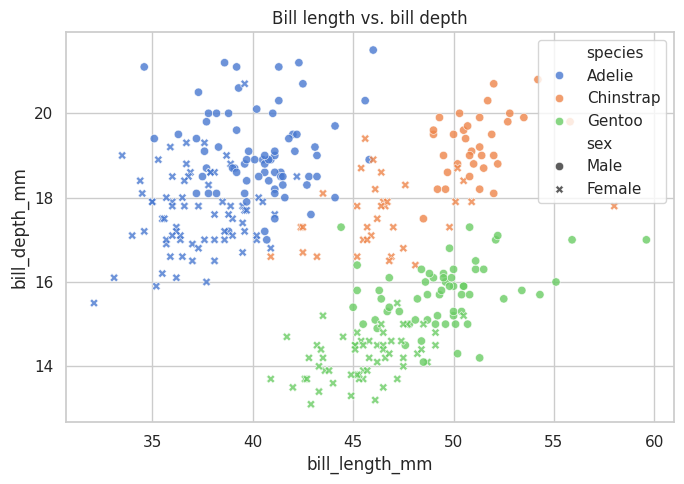

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex",
    alpha=0.8,
    ax=ax,
)
ax.set_title("Bill length vs. bill depth")

plt.tight_layout()
plt.show()

## Staafdiagram — `barplot`

`barplot` toont automatisch het **gemiddelde** (of een andere aggregatie) met een foutbalk voor het betrouwbaarheidsinterval.

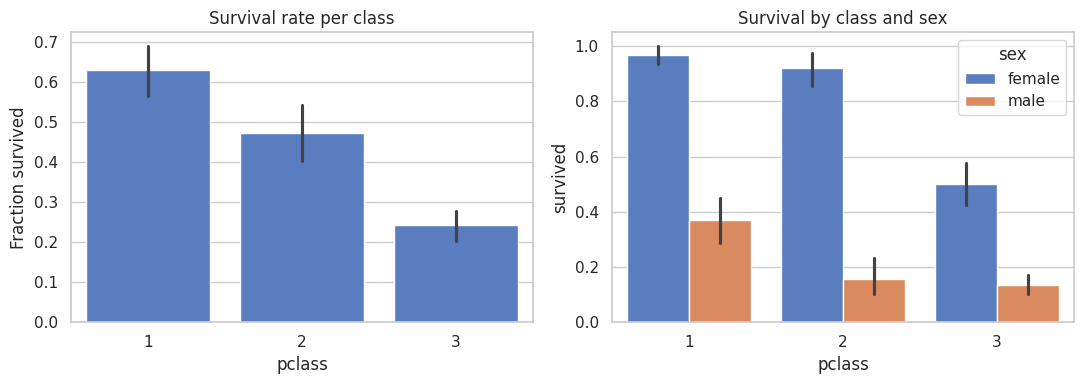

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Survival rate per class
sns.barplot(data=titanic, x="pclass", y="survived", ax=axes[0])
axes[0].set_title("Survival rate per class")
axes[0].set_ylabel("Fraction survived")

# Survival rate per class and sex
sns.barplot(data=titanic, x="pclass", y="survived", hue="sex", ax=axes[1])
axes[1].set_title("Survival by class and sex")

plt.tight_layout()
plt.show()

## Correlatie-heatmap

Een **heatmap** visualiseert een correlatiematrix. Hoge positieve correlatie is donkerrood, hoge negatieve correlatie is donkerblauw. Dit is een van de eerste stappen in een EDA.

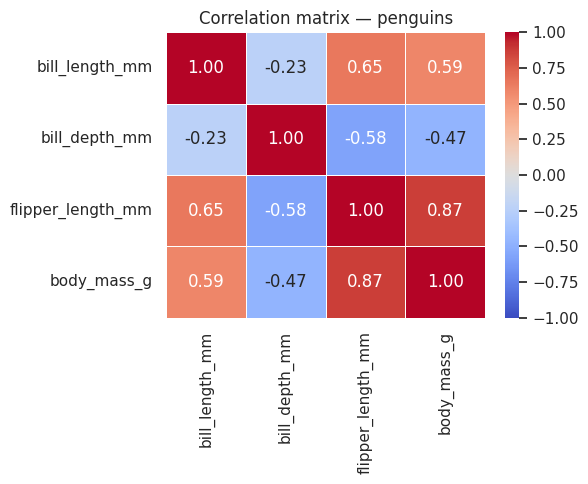

In [6]:
# Compute correlation matrix — numeric columns only
corr = penguins.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,  # show correlation values in cells
    fmt=".2f",  # 2 decimal places
    cmap="coolwarm",  # red = positive, blue = negative
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation matrix — penguins")

plt.tight_layout()
plt.show()

## Pairplot — overzicht van alle variabelen

Een **pairplot** maakt voor elk paar numerieke variabelen een scatter plot, en op de diagonaal een histogram. Ideaal als eerste stap in een EDA om snel patronen te ontdekken.

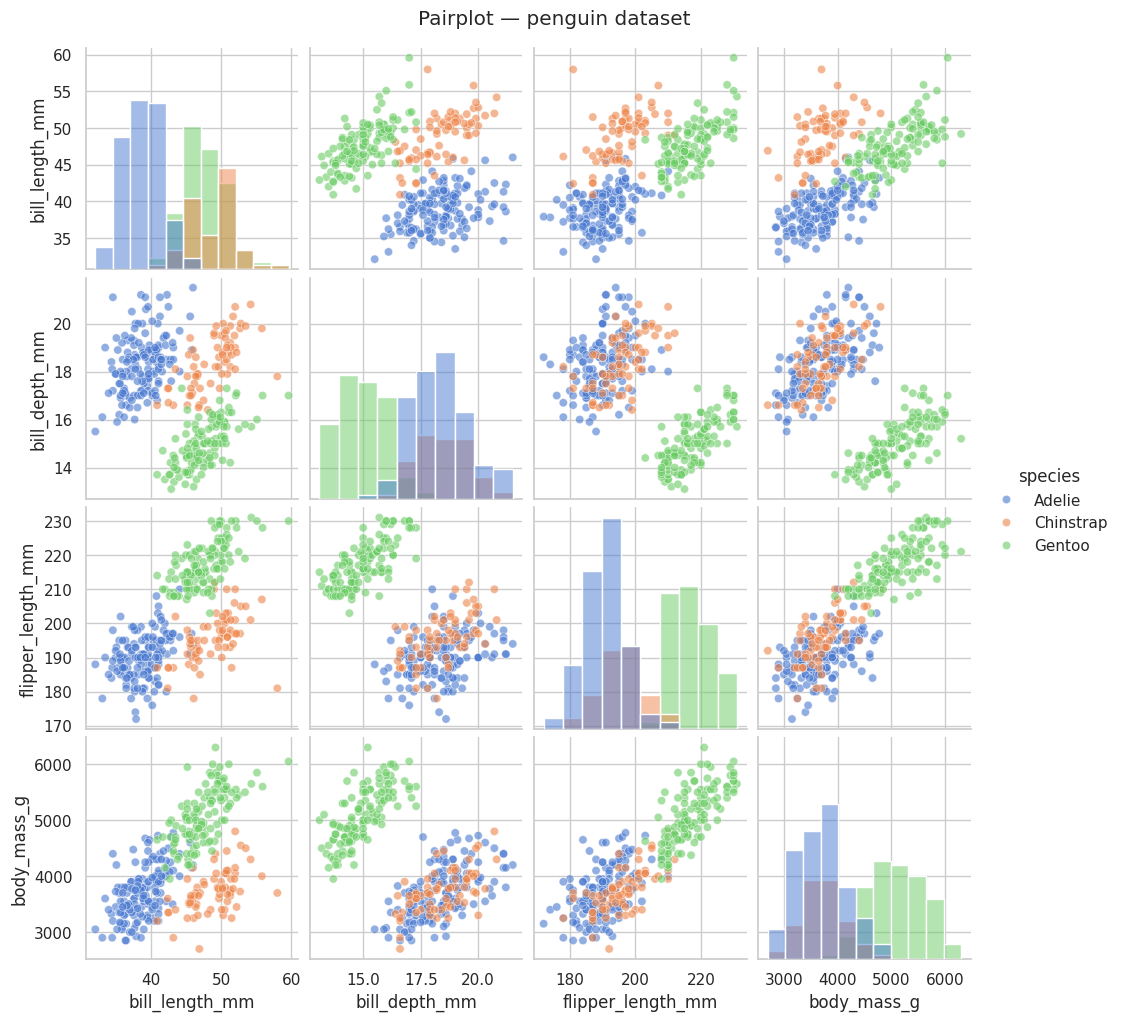

In [7]:
g = sns.pairplot(
    penguins,
    hue="species",
    diag_kind="hist",
    plot_kws={"alpha": 0.6},
)
g.fig.suptitle("Pairplot — penguin dataset", y=1.02)
plt.show()

## Toepassingspatroon in ML-notebooks

In de ML-notebooks kom je dit patroon voortdurend tegen:

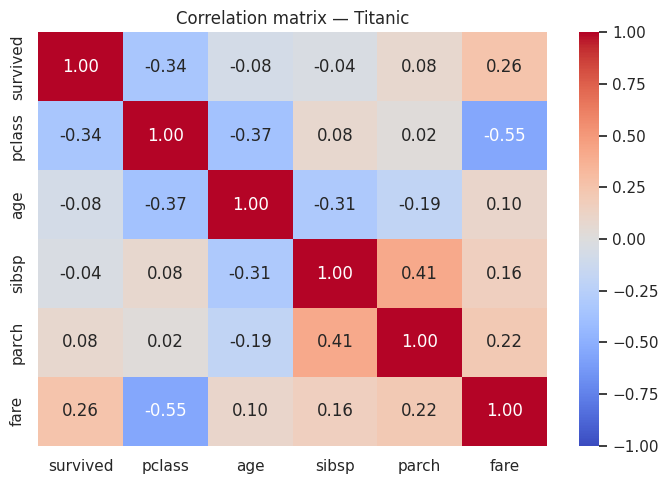

In [8]:
# 1. Compute correlation matrix
numeric_cols = titanic.select_dtypes(include="number")
corr = numeric_cols.corr()

# 2. Visualise
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix — Titanic")
plt.tight_layout()
plt.show()

---

## Oefeningen

**Oefening 1** — Maak een histogram van de leeftijdsverdeling van Titanic-passagiers (`age`), met een KDE-curve en een onderscheid per geslacht (`hue="sex"`). Gebruik 30 bins.

In [9]:
# your solution here

**Oefening 2** — Maak een boxplot van de ticketprijzen (`fare`) per klasse (`pclass`) voor de Titanic-dataset. Wat valt je op over de uitschieters in eerste klas?

In [10]:
# your solution here

**Oefening 3** — Maak een correlatieheatmap voor de numerieke kolommen van de **Tips-dataset**. Welke twee variabelen hebben de sterkste correlatie?

In [11]:
# your solution here

**Oefening 4** — Maak een pairplot voor de Penguins-dataset met `hue="island"`. Welke eilanden overlappen sterk en welk eiland heeft de meest onderscheidende populatie?

In [12]:
# your solution here